# Optimal Trajectory GIFs: 6x6 Grid, 5 Boxes

This notebook visualizes trajectories planned by `solve_state` from `src/optimal_q.py`.

It creates GIFs for one or more seeds, reports metrics, and saves an artifact index.

## 1. Import Dependencies and Project Modules

This cell imports required libraries and resolves repository imports robustly from different notebook working directories.

In [1]:
import json
import os
import sys
from pathlib import Path

# Keep notebook execution on GPU 0 when a CUDA runtime is available.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import imageio.v2 as imageio
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import HTML, Image as IPyImage, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root containing pyproject.toml and src/.")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

try:
    from envs.block_moving.block_moving_env import BoxMovingEnv
    from envs.block_moving.env_types import GridStatesEnum
    from optimal_q import solve_state
except ModuleNotFoundError:
    from src.envs.block_moving.block_moving_env import BoxMovingEnv
    from src.envs.block_moving.env_types import GridStatesEnum
    from src.optimal_q import solve_state

print("Project root:", PROJECT_ROOT)
print("Source root:", SRC_ROOT)
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

Project root: /home/mbortkie/repos/golden-standard
Source root: /home/mbortkie/repos/golden-standard/src
CUDA_VISIBLE_DEVICES: 0


## 2. Configure Environment for 6x6 Grid with 5 Boxes

This sets constants and creates a BoxMoving environment instance.

In [2]:
GRID_SIZE = 6
NUM_BOXES = 5
EPISODE_LENGTH = 300
DISCOUNT = 0.99
SEEDS = [0, 1, 2, 3, 4]

OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "gifs" / "optimal_6x6_5boxes"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

env = BoxMovingEnv(
    grid_size=GRID_SIZE,
    episode_length=EPISODE_LENGTH,
    number_of_boxes_min=NUM_BOXES,
    number_of_boxes_max=NUM_BOXES,
    number_of_moving_boxes_max=NUM_BOXES,
)

ACTION_NAMES = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT",
    4: "PICK_UP",
    5: "PUT_DOWN",
}

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /home/mbortkie/repos/golden-standard/artifacts/gifs/optimal_6x6_5boxes


## 3. Implement Trajectory Rollout with solve_state

This helper rolls out one trajectory for a seed using the planner from optimal_q.

In [3]:
def rollout_optimal(seed: int, discount: float = DISCOUNT) -> dict:
    key = jax.random.PRNGKey(seed)
    state, _ = env.reset(key)

    actions = [int(a) for a in solve_state(state.grid)]
    states = [state]
    rewards = []
    done_flags = []
    truncated_flags = []

    current_state = state
    for action in actions:
        current_state, reward, done, info = env.step(current_state, action)
        states.append(current_state)
        rewards.append(float(reward))
        done_flags.append(bool(done))
        truncated_flags.append(bool(info.get("truncated", False)))
        if bool(done) or bool(info.get("truncated", False)):
            break

    discounted_return = 0.0
    for reward in reversed(rewards):
        discounted_return = discounted_return * discount + reward

    return {
        "seed": seed,
        "actions": actions,
        "states": states,
        "rewards": rewards,
        "done_flags": done_flags,
        "truncated_flags": truncated_flags,
        "planned_actions": len(actions),
        "executed_steps": len(rewards),
        "discounted_return": discounted_return,
        "success": bool(states[-1].success),
    }

## 4. Convert Grid States to Renderable RGB Frames

This section defines a state-to-color palette and a frame renderer with metadata overlays.

In [4]:
MAX_STATE_VALUE = 12
PALETTE = np.zeros((MAX_STATE_VALUE, 3), dtype=np.uint8)

PALETTE[int(GridStatesEnum.EMPTY)] = [245, 245, 245]
PALETTE[int(GridStatesEnum.BOX)] = [184, 134, 11]
PALETTE[int(GridStatesEnum.TARGET)] = [65, 105, 225]
PALETTE[int(GridStatesEnum.AGENT)] = [34, 139, 34]
PALETTE[int(GridStatesEnum.AGENT_CARRYING_BOX)] = [0, 100, 0]
PALETTE[int(GridStatesEnum.AGENT_ON_BOX)] = [107, 142, 35]
PALETTE[int(GridStatesEnum.AGENT_ON_TARGET)] = [30, 144, 255]
PALETTE[int(GridStatesEnum.AGENT_ON_TARGET_CARRYING_BOX)] = [25, 25, 112]
PALETTE[int(GridStatesEnum.AGENT_ON_TARGET_WITH_BOX)] = [70, 130, 180]
PALETTE[int(GridStatesEnum.AGENT_ON_TARGET_WITH_BOX_CARRYING_BOX)] = [72, 61, 139]
PALETTE[int(GridStatesEnum.BOX_ON_TARGET)] = [138, 43, 226]
PALETTE[int(GridStatesEnum.AGENT_ON_BOX_CARRYING_BOX)] = [85, 107, 47]


def render_state_frame(grid: np.ndarray, step_idx: int, action_name: str, reward: float, tile_size: int = 28) -> np.ndarray:
    grid_np = np.asarray(grid, dtype=np.int32)
    rgb = PALETTE[grid_np]
    scaled = np.kron(rgb, np.ones((tile_size, tile_size, 1), dtype=np.uint8))

    canvas = np.pad(scaled, ((34, 0), (0, 0), (0, 0)), constant_values=250)
    img = Image.fromarray(canvas)
    draw = ImageDraw.Draw(img)
    draw.text((8, 8), f"step={step_idx:03d}  action={action_name}  reward={reward:.2f}", fill=(10, 10, 10))
    return np.asarray(img)


def rollout_to_frames(rollout: dict, tile_size: int = 28) -> list[np.ndarray]:
    frames = []
    states = rollout["states"]
    actions = rollout["actions"]
    rewards = rollout["rewards"]

    for i, state in enumerate(states):
        action_name = "START" if i == 0 else ACTION_NAMES.get(actions[i - 1], str(actions[i - 1]))
        reward = 0.0 if i == 0 else rewards[i - 1]
        frame = render_state_frame(np.asarray(state.grid), i, action_name, reward, tile_size=tile_size)
        frames.append(frame)

    return frames


def save_gif(frames: list[np.ndarray], path: Path, fps: float = 5.0) -> Path:
    duration = 1.0 / fps
    imageio.mimsave(path, frames, duration=duration, loop=0)
    return path

## 5. Generate and Save a Single Optimal-Trajectory GIF

Run one seed end-to-end, save a GIF, and display it inline.

{'seed': 0, 'planned_actions': 41, 'executed_steps': 41, 'success': True, 'discounted_return': 0.66897, 'gif': '/home/mbortkie/repos/golden-standard/artifacts/gifs/optimal_6x6_5boxes/optimal_6x6_5boxes_seed0.gif'}


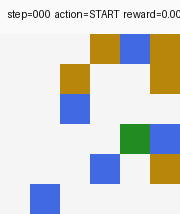

In [5]:
single_seed = SEEDS[0]
single_rollout = rollout_optimal(single_seed)
single_frames = rollout_to_frames(single_rollout, tile_size=30)
single_gif_path = OUTPUT_DIR / f"optimal_6x6_5boxes_seed{single_seed}.gif"
save_gif(single_frames, single_gif_path, fps=5.0)

print(
    {
        "seed": single_seed,
        "planned_actions": single_rollout["planned_actions"],
        "executed_steps": single_rollout["executed_steps"],
        "success": single_rollout["success"],
        "discounted_return": round(single_rollout["discounted_return"], 5),
        "gif": str(single_gif_path),
    }
)

display(IPyImage(filename=str(single_gif_path)))

## 6. Generate Multiple GIFs Across Random Seeds

This loop saves one deterministic GIF per seed into artifacts/gifs/optimal_6x6_5boxes/.

In [6]:
rollouts = []
gif_paths = []

for seed in SEEDS:
    rollout = rollout_optimal(seed)
    frames = rollout_to_frames(rollout, tile_size=30)
    gif_path = OUTPUT_DIR / f"optimal_6x6_5boxes_seed{seed}.gif"
    save_gif(frames, gif_path, fps=5.0)

    rollout["gif_path"] = str(gif_path)
    rollouts.append(rollout)
    gif_paths.append(gif_path)

print(f"Generated {len(gif_paths)} GIFs in {OUTPUT_DIR}")
for p in gif_paths:
    print(p.name)

Generated 5 GIFs in /home/mbortkie/repos/golden-standard/artifacts/gifs/optimal_6x6_5boxes
optimal_6x6_5boxes_seed0.gif
optimal_6x6_5boxes_seed1.gif
optimal_6x6_5boxes_seed2.gif
optimal_6x6_5boxes_seed3.gif
optimal_6x6_5boxes_seed4.gif


## 7. Collect Validation Metrics for Planned Trajectories

Build a metrics table and summarize planner outcomes.

In [7]:
metrics_rows = []
for rollout in rollouts:
    metrics_rows.append(
        {
            "seed": rollout["seed"],
            "planned_actions": rollout["planned_actions"],
            "executed_steps": rollout["executed_steps"],
            "discounted_return": rollout["discounted_return"],
            "success": rollout["success"],
            "gif_path": rollout["gif_path"],
        }
    )

metrics_df = pd.DataFrame(metrics_rows).sort_values("seed").reset_index(drop=True)

display(metrics_df)
print("Summary statistics:")
display(metrics_df[["planned_actions", "executed_steps", "discounted_return"]].describe())
print("Success rate:", metrics_df["success"].mean())

,seed,planned_actions,executed_steps,discounted_return,success,gif_path
0,0,41,41,0.668972,True,/home/mbortkie/repos/golden-standard/artifacts...
1,1,32,32,0.732303,True,/home/mbortkie/repos/golden-standard/artifacts...
2,2,49,49,0.617290,True,/home/mbortkie/repos/golden-standard/artifacts...
3,3,35,35,0.710553,True,/home/mbortkie/repos/golden-standard/artifacts...
4,4,27,27,0.770043,True,/home/mbortkie/repos/golden-standard/artifacts...


Summary statistics:


,planned_actions,executed_steps,discounted_return
count,5.000000,5.000000,5.000000
mean,36.800000,36.800000,0.699832
std,8.497058,8.497058,0.058874
min,27.000000,27.000000,0.617290
25%,32.000000,32.000000,0.668972
50%,35.000000,35.000000,0.710553
75%,41.000000,41.000000,0.732303
max,49.000000,49.000000,0.770043


Success rate: 1.0


## 8. Display GIFs Inline and Save Artifact Index

This creates a compact inline gallery and writes CSV/JSON index files for downstream use.

In [8]:
index_csv_path = OUTPUT_DIR / "trajectory_metrics_index.csv"
index_json_path = OUTPUT_DIR / "trajectory_metrics_index.json"

metrics_df.to_csv(index_csv_path, index=False)
with open(index_json_path, "w", encoding="utf-8") as f:
    json.dump(metrics_rows, f, indent=2)

cards = []
for row in metrics_rows:
    cards.append(
        f"""
        <div style='display:inline-block; margin:12px; text-align:center;'>
            <div><strong>Seed {row['seed']}</strong></div>
            <div style='font-size:12px;'>steps={row['executed_steps']} success={row['success']}</div>
            <img src='{Path(row['gif_path']).as_posix()}' width='220' />
        </div>
        """
    )

gallery_html = "<div style='display:flex; flex-wrap:wrap;'>" + "\n".join(cards) + "</div>"
display(HTML(gallery_html))

print("Saved artifact index files:")
print(index_csv_path)
print(index_json_path)

Saved artifact index files:
/home/mbortkie/repos/golden-standard/artifacts/gifs/optimal_6x6_5boxes/trajectory_metrics_index.csv
/home/mbortkie/repos/golden-standard/artifacts/gifs/optimal_6x6_5boxes/trajectory_metrics_index.json
